# Style Model Eval and Loss Plots

This notebook plots eval CSVs (ADP/SL/WP/Random/RLCard) and training losses from `logs.csv`.
It keeps frames on the x-axis when available and otherwise falls back to row index.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "semibold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": False,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
    }
)

SMOOTHING_CONFIG = {
    "eval": {"min_window": 5, "max_window": 31, "target_points": 24, "ewm_span": 7},
    "loss": {
        "min_window": 81,
        "max_window": 601,
        "target_points": 80,
        "ewm_span": 61,
        "band_quantiles": (0.2, 0.8),
        "band_window_ratio": 0.35,
        "band_alpha": 0.14,
        "raw_alpha": 0.10,
    },
}


def compute_smoothing_window(length: int, min_window: int, max_window: int, target_points: int) -> int:
    if length <= 2:
        return 1
    window = max(min_window, int(np.ceil(length / max(target_points, 1))))
    window = min(window, max_window)
    if window % 2 == 0:
        window += 1
    if window > max_window:
        window = max_window if max_window % 2 == 1 else max_window - 1
    return max(window, 1)


def smooth_series(
    series: pd.Series,
    *,
    min_window: int,
    max_window: int,
    target_points: int,
    ewm_span: int,
    clip_quantile: float | None = None,
    zero_as_missing: bool = False,
    center: bool = True,
    min_period_ratio: float = 0.2,
) -> pd.Series:
    work_series = pd.to_numeric(series, errors="coerce").copy()
    if zero_as_missing:
        work_series = work_series.mask(work_series == 0)
    if work_series.notna().sum() <= 2:
        return work_series

    if clip_quantile is not None:
        upper_clip = work_series.dropna().quantile(clip_quantile)
        if pd.notna(upper_clip):
            work_series = work_series.clip(upper=upper_clip)

    window = compute_smoothing_window(len(work_series.dropna()), min_window, max_window, target_points)
    min_periods = max(3, int(np.ceil(window * min_period_ratio)))
    smoothed = work_series.rolling(window=window, center=center, min_periods=min_periods).median()
    smoothed = smoothed.interpolate(limit_direction="both")

    if ewm_span > 1 and smoothed.notna().sum() > 2:
        ewm_min_periods = max(3, ewm_span // 3)
        smoothed = smoothed.ewm(span=ewm_span, adjust=False, min_periods=ewm_min_periods).mean()
        smoothed = smoothed.interpolate(limit_direction="both")

    return smoothed


def format_frames_in_millions(value, _pos):
    value_millions = value / 1_000_000
    if np.isclose(value_millions, round(value_millions), atol=1e-6):
        return f"{int(round(value_millions))}M"
    return f"{value_millions:.1f}M"


def apply_frame_axis_format(ax, axis_label: str):
    if axis_label != "frames":
        return axis_label
    ax.xaxis.set_major_formatter(FuncFormatter(format_frames_in_millions))
    ax.xaxis.offsetText.set_visible(False)
    return "frames (M)"


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for cand in candidates:
        if (cand / "douzero_checkpoints").exists():
            return cand
    return start


def make_eval_files(csv_dir: Path) -> dict:
    return {
        "adp": csv_dir / "adp_eval.csv",
        "sl": csv_dir / "sl_eval.csv",
        "wp": csv_dir / "wp_eval.csv",
        "random": csv_dir / "random_eval.csv",
        "rlcard": csv_dir / "rlcard_eval.csv",
    }


def find_model_csv_dir(model_dir: Path) -> Path | None:
    direct_logs = model_dir / "logs.csv"
    nested_logs_dir = model_dir / "logs"
    nested_logs = nested_logs_dir / "logs.csv"
    if nested_logs.exists():
        return nested_logs_dir
    if direct_logs.exists():
        return model_dir
    return None


def discover_model_runs(repo_root: Path, group_name: str) -> dict:
    group_dir = repo_root / "douzero_checkpoints" / group_name
    runs = {}
    if not group_dir.exists():
        return runs
    for model_dir in sorted(path for path in group_dir.iterdir() if path.is_dir()):
        csv_dir = find_model_csv_dir(model_dir)
        if csv_dir is None:
            continue
        logs_csv = csv_dir / "logs.csv"
        eval_files = make_eval_files(csv_dir) if group_name == "style" else {}
        runs[model_dir.name] = {
            "group": group_name,
            "name": model_dir.name,
            "model_dir": model_dir,
            "csv_dir": csv_dir,
            "logs_csv": logs_csv,
            "eval_files": eval_files,
        }
    return runs


repo_root = find_repo_root(Path.cwd())
style_runs = discover_model_runs(repo_root, "style")
baseline_runs = discover_model_runs(repo_root, "baseline")
all_runs = {**style_runs, **baseline_runs}

plots_dir = repo_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
style_eval_plot_path = plots_dir / "style_eval_grid.png"
style_loss_plot_path = plots_dir / "style_training_losses.png"
baseline_loss_plot_path = plots_dir / "baseline_training_losses.png"
comparison_plot_path = plots_dir / "model_loss_comparison.png"

print("Repo root:", repo_root)
print("Style runs:", list(style_runs))
for name, run in style_runs.items():
    print(f"  {name}: csv_dir={run['csv_dir']}")
    for eval_name, eval_path in run["eval_files"].items():
        print(f"    {eval_name}: {eval_path.exists()} -> {eval_path}")
    print(f"    training logs: {run['logs_csv'].exists()} -> {run['logs_csv']}")

print("Baseline runs:", list(baseline_runs))
for name, run in baseline_runs.items():
    print(f"  {name}: csv_dir={run['csv_dir']}")
    print(f"    training logs: {run['logs_csv'].exists()} -> {run['logs_csv']}")

print("style eval plot will be saved to:", style_eval_plot_path)
print("style training plot will be saved to:", style_loss_plot_path)
print("baseline training plot will be saved to:", baseline_loss_plot_path)
print("comparison plot will be saved to:", comparison_plot_path)


Repo root: /home/users/yf201/Code/RL-Project/StyleDou
Style runs: ['style_model', 'style_model_new']
  style_model: csv_dir=/home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs
    adp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/adp_eval.csv
    sl: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/sl_eval.csv
    wp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/wp_eval.csv
    random: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/random_eval.csv
    rlcard: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/rlcard_eval.csv
    training logs: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/logs.csv
  style_model_new: csv_dir=/home/users/yf201/Code/RL-Project/StyleDou/douzero_ch

## Section 1: Style Evaluation

Evaluation curves for the two style models only.

Latest style_model evaluation:, date=2026-04-13 21:37:17 EDT, frames=996,060,800, source=style_model:adp, test_type=ADP, role=farmer
Latest style_model_new evaluation:, date=2026-04-16 08:29:31 EDT, frames=335,257,600, source=style_model_new:sl, test_type=SL, role=farmer
Saved eval plot to /home/users/yf201/Code/RL-Project/StyleDou/plots/style_eval_grid.png


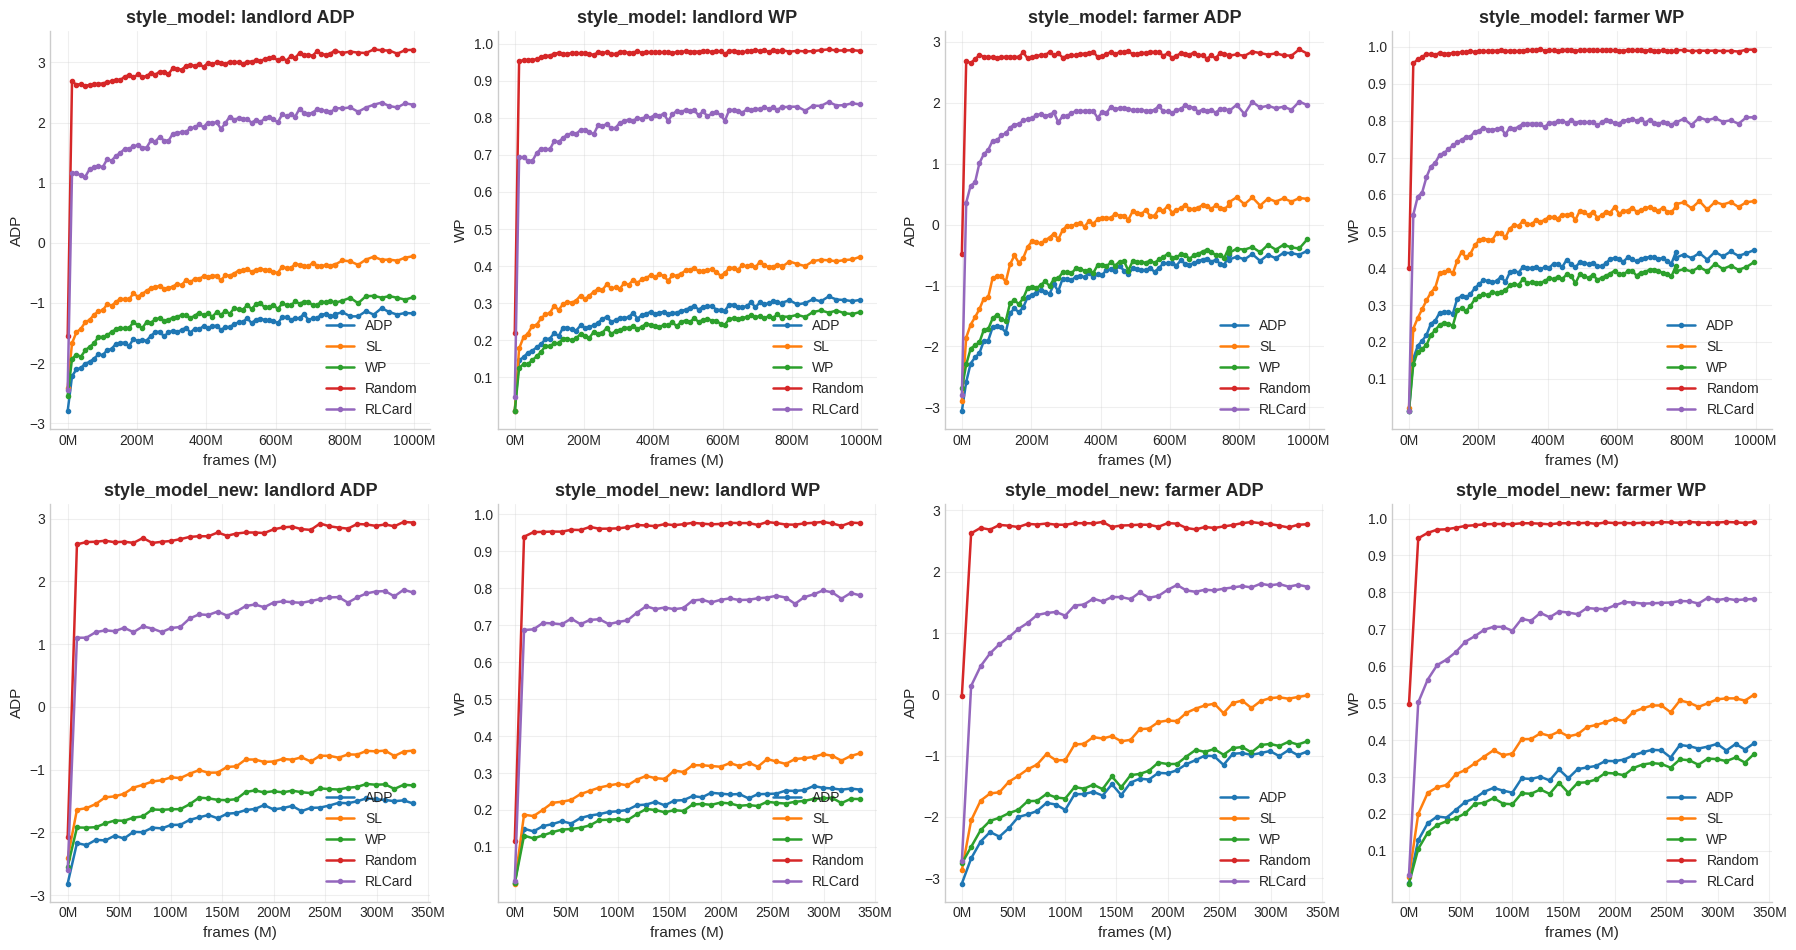

In [3]:
def load_eval_csv(path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def get_elapsed_seconds(df):
    if "time_seconds" in df.columns:
        series = pd.to_numeric(df["time_seconds"], errors="coerce")
        if series.notna().any():
            return series
    if "_time" in df.columns:
        series = pd.to_numeric(df["_time"], errors="coerce")
        if series.notna().any():
            return series - series.dropna().iloc[0]
    return None


def prepare_plot_axis(df):
    if "frames" in df.columns:
        frames = pd.to_numeric(df["frames"], errors="coerce")
        if frames.notna().any():
            return frames, "frames"
    return pd.Series(range(len(df)), index=df.index, dtype=float), "index"


def get_eval_label(test_type):
    label_map = {
        "adp": "ADP",
        "sl": "SL",
        "wp": "WP",
        "random": "Random",
        "rlcard": "RLCard",
    }
    return label_map.get(test_type, str(test_type).upper())


def get_latest_row_info(df, source_name=None):
    if df is None or df.empty:
        return None
    work_df = df.copy()
    sort_col = None
    timestamp = None
    if "timestamp" in work_df.columns:
        work_df["_sort_timestamp"] = pd.to_datetime(work_df["timestamp"], errors="coerce", utc=True)
        if work_df["_sort_timestamp"].notna().any():
            sort_col = "_sort_timestamp"
    if sort_col is None and "_time" in work_df.columns:
        work_df["_sort_time"] = pd.to_numeric(work_df["_time"], errors="coerce")
        if work_df["_sort_time"].notna().any():
            sort_col = "_sort_time"
    if sort_col is None and "time_seconds" in work_df.columns:
        work_df["_sort_elapsed"] = pd.to_numeric(work_df["time_seconds"], errors="coerce")
        if work_df["_sort_elapsed"].notna().any():
            sort_col = "_sort_elapsed"
    if sort_col is None and "frames" in work_df.columns:
        work_df["_sort_frames"] = pd.to_numeric(work_df["frames"], errors="coerce")
        if work_df["_sort_frames"].notna().any():
            sort_col = "_sort_frames"
    if sort_col is None:
        latest = work_df.iloc[-1]
    else:
        latest = work_df.sort_values(sort_col).iloc[-1]
    if "timestamp" in latest and pd.notna(latest.get("timestamp")):
        timestamp = pd.to_datetime(latest["timestamp"], errors="coerce", utc=True)
    elif "_time" in latest and pd.notna(latest.get("_time")):
        timestamp = pd.to_datetime(float(latest["_time"]), unit="s", utc=True)
    frames = pd.to_numeric(latest.get("frames"), errors="coerce") if "frames" in latest.index else np.nan
    info = {
        "source": source_name,
        "timestamp": timestamp,
        "frames": int(frames) if pd.notna(frames) else None,
    }
    for col in ["test_type", "role"]:
        if col in latest.index and pd.notna(latest[col]):
            info[col] = latest[col]
    return info


def format_latest_row_info(label, info):
    if info is None:
        print(f"Latest {label}: unavailable")
        return
    parts = [f"Latest {label}:"]
    if info.get("timestamp") is not None and pd.notna(info["timestamp"]):
        parts.append(f"date={info['timestamp'].tz_convert('America/New_York').strftime('%Y-%m-%d %H:%M:%S %Z')}")
    if info.get("frames") is not None:
        parts.append(f"frames={info['frames']:,}")
    if info.get("source"):
        parts.append(f"source={info['source']}")
    if info.get("test_type"):
        parts.append(f"test_type={info['test_type']}")
    if info.get("role"):
        parts.append(f"role={info['role']}")
    print(", ".join(parts))


def plot_eval_grid(style_runs):
    if not style_runs:
        print("No style runs found; skipping eval plots.")
        return

    run_names = list(style_runs)
    fig, axes = plt.subplots(len(run_names), 4, figsize=(18, 4.8 * len(run_names)), sharex=False, squeeze=False)
    metric_specs = [
        ("landlord", "adp", "ADP"),
        ("landlord", "wp", "WP"),
        ("farmer", "adp", "ADP"),
        ("farmer", "wp", "WP"),
    ]

    for row_idx, run_name in enumerate(run_names):
        eval_data = {
            test_type: load_eval_csv(path)
            for test_type, path in style_runs[run_name]["eval_files"].items()
        }
        latest_eval_candidates = [
            get_latest_row_info(df, source_name=f"{run_name}:{test_type}")
            for test_type, df in eval_data.items()
        ]
        latest_eval_candidates = [info for info in latest_eval_candidates if info is not None]
        latest_eval = None
        if latest_eval_candidates:
            latest_eval = max(
                latest_eval_candidates,
                key=lambda info: info["timestamp"] if info.get("timestamp") is not None else pd.Timestamp.min.tz_localize("UTC"),
            )
        format_latest_row_info(f"{run_name} evaluation", latest_eval)

        for col_idx, (role, metric_key, metric_label) in enumerate(metric_specs):
            ax = axes[row_idx, col_idx]
            has_series = False
            x_label = "index"
            metric_col = f"{metric_key}_{role}"
            for test_type, df in eval_data.items():
                if df is None or df.empty or "role" not in df.columns or metric_col not in df.columns:
                    continue
                role_df = df[df["role"] == role].copy()
                if role_df.empty:
                    continue
                if "frames" in role_df.columns:
                    role_df = role_df.sort_values("frames")
                elif "time_seconds" in role_df.columns:
                    role_df = role_df.sort_values("time_seconds")
                x, x_label = prepare_plot_axis(role_df)
                metric_series = pd.to_numeric(role_df[metric_col], errors="coerce")
                ax.plot(x, metric_series, linewidth=1.8, marker="o", markersize=3, label=get_eval_label(test_type))
                has_series = True
            x_label = apply_frame_axis_format(ax, x_label)
            ax.set_title(f"{run_name}: {role} {metric_label}")
            ax.set_xlabel(x_label)
            ax.set_ylabel(metric_label)
            if metric_key == "wp":
                ax.set_yticks(np.arange(0.1, 1.01, 0.1))
            ax.grid(True, alpha=0.3)
            if has_series:
                ax.legend(loc="lower right")
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    fig.tight_layout()
    fig.savefig(style_eval_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved eval plot to {style_eval_plot_path}")
    plt.show()


plot_eval_grid(style_runs)


## Section 2: Training Losses

Per-model training loss plots for all four models. Style models include both main loss and aux loss.

style_model cleanup: detected 1 frame rollback(s) and 3,095 duplicated frame value(s); keeping the latest row for each frame.
Latest style_model loss:, date=2026-04-13 21:44:40 EDT, frames=1,000,147,200, source=style_model
style_model duration: 144.27 hours (6.01 days)
style_model_new cleanup: detected 2 frame rollback(s) and 43 duplicated frame value(s); keeping the latest row for each frame.
Latest style_model_new loss:, date=2026-04-16 09:15:18 EDT, frames=345,452,800, source=style_model_new
style_model_new duration: 38.13 hours (1.59 days)
baseline cleanup: detected 2 frame rollback(s) and 2,290 duplicated frame value(s); keeping the latest row for each frame.
Latest baseline loss:, date=2026-04-16 08:16:42 EDT, frames=500,108,800, source=baseline
baseline duration: 37.39 hours (1.56 days)
Latest baseline_v100 loss:, date=2026-04-16 09:15:18 EDT, frames=274,083,200, source=baseline_v100
baseline_v100 duration: 38.15 hours (1.59 days)
Saved training plot to /home/users/yf201/Code/RL

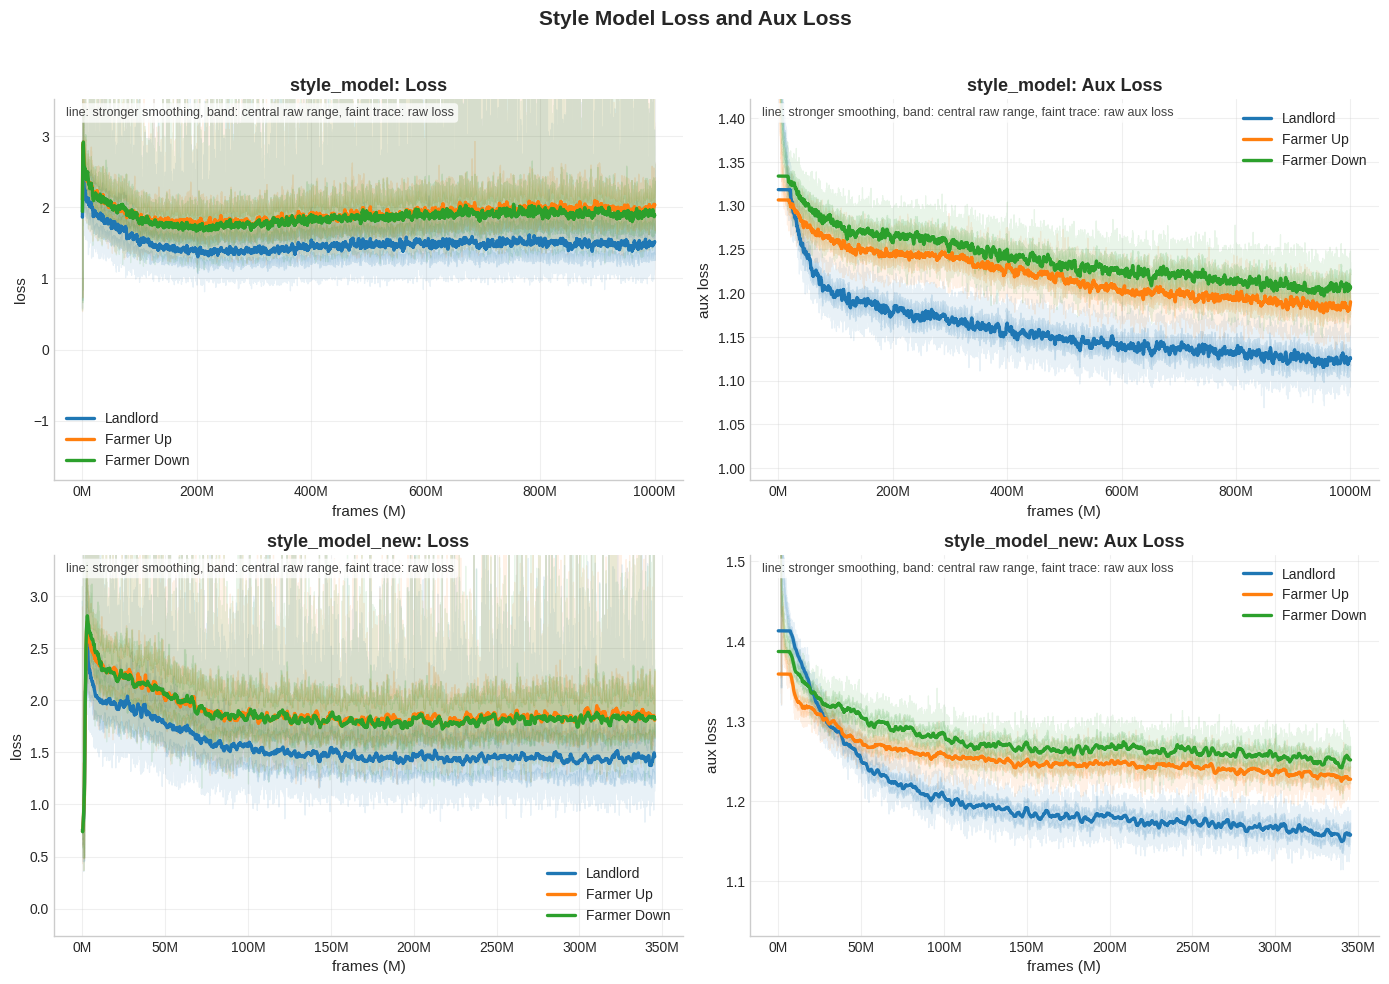

Saved training plot to /home/users/yf201/Code/RL-Project/StyleDou/plots/baseline_training_losses.png


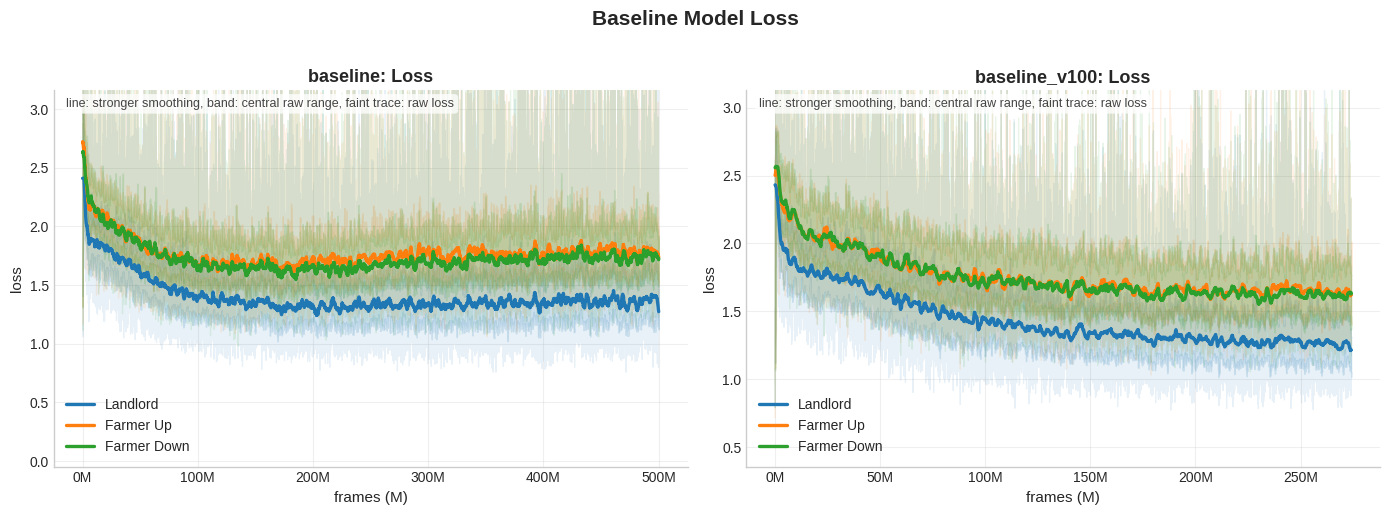

In [4]:
def load_training_logs(path: Path):
    if path is None or not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        first_line = handle.readline().strip()
    header = None
    if first_line.startswith("#"):
        header = [c.strip() for c in first_line.lstrip("# ").split(",")]
    if header:
        df = pd.read_csv(path, comment="#", names=header)
    else:
        df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def keep_latest_training_segment(df):
    if df is None or df.empty or "frames" not in df.columns:
        return df, {"rollback_count": 0, "duplicate_frame_count": 0}
    work_df = df.copy()
    work_df["_frames_numeric"] = pd.to_numeric(work_df["frames"], errors="coerce")
    valid_frames = work_df["_frames_numeric"].dropna()
    if len(valid_frames) < 2:
        return work_df.drop(columns=["_frames_numeric"]), {"rollback_count": 0, "duplicate_frame_count": 0}
    frame_diffs = work_df["_frames_numeric"].diff()
    rollback_count = int((frame_diffs < 0).sum())
    duplicate_frame_count = int(valid_frames[valid_frames.duplicated(keep=False)].nunique())
    work_df = work_df.dropna(subset=["_frames_numeric"]).copy()
    work_df = work_df.sort_values("_frames_numeric", kind="stable")
    work_df = work_df.drop_duplicates(subset="_frames_numeric", keep="last")
    stats = {
        "rollback_count": rollback_count,
        "duplicate_frame_count": duplicate_frame_count,
    }
    return work_df.drop(columns=["_frames_numeric"]), stats


def get_role_label(column_name: str) -> str:
    role_map = {
        "landlord": "Landlord",
        "landlord_up": "Farmer Up",
        "landlord_down": "Farmer Down",
    }
    role_key = column_name.split("loss_")[-1]
    return role_map.get(role_key, column_name)


def get_metric_columns(df, prefix: str):
    expected = [
        f"{prefix}_landlord",
        f"{prefix}_landlord_up",
        f"{prefix}_landlord_down",
    ]
    return [col for col in expected if col in df.columns]


def prepare_training_df(logs_csv: Path, run_name: str):
    train_df = load_training_logs(logs_csv)
    if train_df is None or train_df.empty:
        print(f"{run_name}: logs.csv not found or empty")
        return None

    train_plot_df = train_df.copy()
    train_plot_df, cleanup_stats = keep_latest_training_segment(train_plot_df)
    rollback_count = cleanup_stats["rollback_count"]
    duplicate_frame_count = cleanup_stats["duplicate_frame_count"]
    if rollback_count or duplicate_frame_count:
        print(
            f"{run_name} cleanup: detected {rollback_count} frame rollback(s) and "
            f"{duplicate_frame_count:,} duplicated frame value(s); keeping the latest row for each frame."
        )

    if "frames" in train_plot_df.columns:
        frame_values = pd.to_numeric(train_plot_df["frames"], errors="coerce")
        train_plot_df = train_plot_df[frame_values > 0].copy()

    if train_plot_df.empty:
        print(f"{run_name}: no rows remain after removing frame 0.")
        return None

    elapsed_seconds = get_elapsed_seconds(train_plot_df)
    format_latest_row_info(f"{run_name} loss", get_latest_row_info(train_plot_df, source_name=run_name))
    valid_elapsed = pd.to_numeric(elapsed_seconds, errors="coerce").dropna() if elapsed_seconds is not None else pd.Series(dtype=float)
    if not valid_elapsed.empty:
        total_hours = valid_elapsed.max() / 3600
        print(f"{run_name} duration: {total_hours:.2f} hours ({total_hours / 24:.2f} days)")

    return train_plot_df


def plot_smoothed_series(ax, x_values, series, label):
    valid_mask = series.notna() & (series != 0)
    valid_x = x_values[valid_mask]
    valid_y = pd.to_numeric(series[valid_mask], errors="coerce")
    if valid_y.empty:
        return None

    smoothed_y = smooth_series(
        valid_y,
        min_window=SMOOTHING_CONFIG["loss"]["min_window"],
        max_window=SMOOTHING_CONFIG["loss"]["max_window"],
        target_points=SMOOTHING_CONFIG["loss"]["target_points"],
        ewm_span=SMOOTHING_CONFIG["loss"]["ewm_span"],
        clip_quantile=0.98,
        zero_as_missing=True,
    )

    band_window = max(11, int(SMOOTHING_CONFIG["loss"]["max_window"] * SMOOTHING_CONFIG["loss"]["band_window_ratio"]))
    if band_window % 2 == 0:
        band_window += 1
    band_min_periods = max(3, band_window // 5)
    lower_quantile, upper_quantile = SMOOTHING_CONFIG["loss"]["band_quantiles"]
    band_lower = valid_y.rolling(window=band_window, center=True, min_periods=band_min_periods).quantile(lower_quantile)
    band_upper = valid_y.rolling(window=band_window, center=True, min_periods=band_min_periods).quantile(upper_quantile)
    band_lower = band_lower.interpolate(limit_direction="both")
    band_upper = band_upper.interpolate(limit_direction="both")

    raw_line, = ax.plot(
        valid_x,
        valid_y,
        linewidth=0.9,
        alpha=SMOOTHING_CONFIG["loss"]["raw_alpha"],
        zorder=1,
    )
    band_mask = band_lower.notna() & band_upper.notna() & (band_upper >= band_lower)
    if band_mask.any():
        ax.fill_between(
            valid_x,
            band_lower,
            band_upper,
            where=band_mask,
            interpolate=True,
            color=raw_line.get_color(),
            alpha=SMOOTHING_CONFIG["loss"]["band_alpha"],
            zorder=1,
        )

    ax.plot(valid_x, smoothed_y, linewidth=2.4, label=label, color=raw_line.get_color(), zorder=2)
    y_top = max(
        smoothed_y.dropna().quantile(0.99) if smoothed_y.notna().any() else np.nan,
        band_upper.dropna().quantile(0.99) if band_upper.notna().any() else np.nan,
        valid_y.quantile(0.99),
    )
    if pd.isna(y_top):
        return None
    y_bottom = min(
        smoothed_y.dropna().min() if smoothed_y.notna().any() else np.nan,
        band_lower.dropna().min() if band_lower.notna().any() else np.nan,
        valid_y.min(),
    )
    if pd.isna(y_bottom):
        y_bottom = valid_y.min()
    y_pad = max((y_top - y_bottom) * 0.08, 0.01)
    return y_top + y_pad


def add_metric_description(ax, prefix: str):
    description = "line: stronger smoothing, band: central raw range, faint trace: raw loss"
    if prefix == "aux_loss":
        description = "line: stronger smoothing, band: central raw range, faint trace: raw aux loss"
    ax.text(
        0.02,
        0.98,
        description,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="#444444",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "boxstyle": "round,pad=0.3"},
    )


def plot_run_metric(ax, train_plot_df, run_name: str, prefix: str, title_suffix: str):
    metric_cols = get_metric_columns(train_plot_df, prefix)
    x, x_label = prepare_plot_axis(train_plot_df)
    if not metric_cols:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{run_name}: {title_suffix}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(title_suffix.lower())
        ax.grid(True, alpha=0.3)
        return

    top_limits = []
    for col in metric_cols:
        series = pd.to_numeric(train_plot_df[col], errors="coerce")
        top_limit = plot_smoothed_series(ax, x, series, get_role_label(col))
        if top_limit is not None:
            top_limits.append(top_limit)

    if top_limits:
        ax.set_ylim(top=max(top_limits))
    x_label = apply_frame_axis_format(ax, x_label)
    add_metric_description(ax, prefix)
    ax.legend()
    ax.set_title(f"{run_name}: {title_suffix}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(title_suffix.lower())
    ax.grid(True, alpha=0.3)


def plot_style_loss_grid(style_runs: dict, prepared_training_runs: dict):
    if not style_runs:
        print("No style runs found; skipping style loss plot.")
        return

    run_names = list(style_runs)
    fig, axes = plt.subplots(len(run_names), 2, figsize=(14, 4.8 * len(run_names)), sharex=False, squeeze=False)
    for idx, run_name in enumerate(run_names):
        train_plot_df = prepared_training_runs.get(run_name)
        if train_plot_df is None:
            for col_idx, title_suffix in enumerate(["Loss", "Aux Loss"]):
                ax = axes[idx, col_idx]
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{run_name}: {title_suffix}")
                ax.set_xlabel("frames")
                ax.set_ylabel(title_suffix.lower())
                ax.grid(True, alpha=0.3)
            continue
        plot_run_metric(axes[idx, 0], train_plot_df, run_name, "loss", "Loss")
        plot_run_metric(axes[idx, 1], train_plot_df, run_name, "aux_loss", "Aux Loss")

    fig.suptitle("Style Model Loss and Aux Loss", y=1.02, fontsize=15, fontweight="semibold")
    fig.tight_layout()
    fig.savefig(style_loss_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved training plot to {style_loss_plot_path}")
    plt.show()


def plot_baseline_loss_grid(baseline_runs: dict, prepared_training_runs: dict):
    if not baseline_runs:
        print("No baseline runs found; skipping baseline loss plot.")
        return

    run_names = list(baseline_runs)
    fig, axes = plt.subplots(1, len(run_names), figsize=(7 * len(run_names), 5), sharex=False, squeeze=False)
    for idx, run_name in enumerate(run_names):
        train_plot_df = prepared_training_runs.get(run_name)
        ax = axes[0, idx]
        if train_plot_df is None:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{run_name}: Loss")
            ax.set_xlabel("frames")
            ax.set_ylabel("loss")
            ax.grid(True, alpha=0.3)
            continue
        plot_run_metric(ax, train_plot_df, run_name, "loss", "Loss")

    fig.suptitle("Baseline Model Loss", y=1.02, fontsize=15, fontweight="semibold")
    fig.tight_layout()
    fig.savefig(baseline_loss_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved training plot to {baseline_loss_plot_path}")
    plt.show()


prepared_training_runs = {}
for run_name, run in all_runs.items():
    prepared_training_runs[run_name] = prepare_training_df(run["logs_csv"], run_name)


plot_style_loss_grid(style_runs, prepared_training_runs)
plot_baseline_loss_grid(baseline_runs, prepared_training_runs)


## Section 3: Comparison

Role-by-role loss comparison across all four models, truncated to the shortest trained frame.

Comparison frame cap: 274,083,200 frames


Saved comparison plot to /home/users/yf201/Code/RL-Project/StyleDou/plots/model_loss_comparison.png


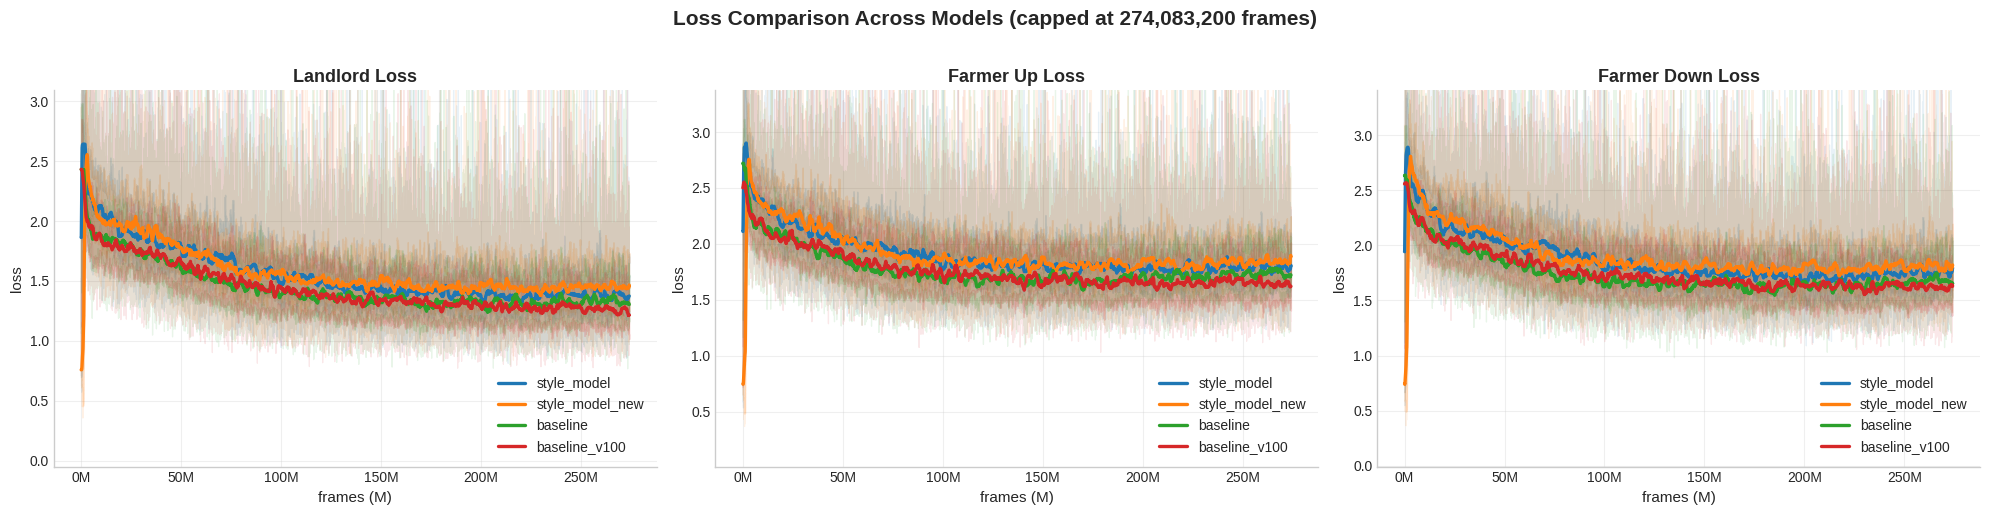

: 

In [ ]:
def plot_loss_comparison(all_runs: dict, prepared_training_runs: dict):
    available_runs = {
        run_name: df
        for run_name, df in prepared_training_runs.items()
        if df is not None and "frames" in df.columns
    }
    if not available_runs:
        print("No comparable training runs found; skipping comparison plot.")
        return

    max_frames = {}
    for run_name, df in available_runs.items():
        frame_values = pd.to_numeric(df["frames"], errors="coerce").dropna()
        if frame_values.empty:
            continue
        max_frames[run_name] = frame_values.max()
    if not max_frames:
        print("No valid frame data found; skipping comparison plot.")
        return

    frame_cap = min(max_frames.values())
    print(f"Comparison frame cap: {int(frame_cap):,} frames")

    role_specs = [
        ("loss_landlord", "Landlord Loss"),
        ("loss_landlord_up", "Farmer Up Loss"),
        ("loss_landlord_down", "Farmer Down Loss"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=False, squeeze=False)
    axes = axes[0]

    for ax, (loss_col, title) in zip(axes, role_specs):
        has_series = False
        top_limits = []
        for run_name in all_runs:
            train_plot_df = available_runs.get(run_name)
            if train_plot_df is None or loss_col not in train_plot_df.columns:
                continue
            frame_values = pd.to_numeric(train_plot_df["frames"], errors="coerce")
            clipped_df = train_plot_df[frame_values <= frame_cap].copy()
            if clipped_df.empty:
                continue
            x_values = pd.to_numeric(clipped_df["frames"], errors="coerce")
            series = pd.to_numeric(clipped_df[loss_col], errors="coerce")
            top_limit = plot_smoothed_series(ax, x_values, series, run_name)
            if top_limit is not None:
                top_limits.append(top_limit)
                has_series = True
        if top_limits:
            ax.set_ylim(top=max(top_limits))
        x_label = apply_frame_axis_format(ax, "frames")
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("loss")
        ax.grid(True, alpha=0.3)
        if has_series:
            ax.legend()
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    fig.suptitle(
        f"Loss Comparison Across Models (capped at {int(frame_cap):,} frames)",
        y=1.02,
        fontsize=15,
        fontweight="semibold",
    )
    fig.tight_layout()
    fig.savefig(comparison_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved comparison plot to {comparison_plot_path}")
    plt.show()


plot_loss_comparison(all_runs, prepared_training_runs)
